In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../Mamoth Modules")

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def process_greek(dataframe, column):
    _RE_COMBINE_WHITESPACE = re.compile(r"\s+")

    dataframe[column] = dataframe[column].apply(lambda x : x.strip())
    dataframe[column] = dataframe[column].apply(lambda x : x.lower())
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ά','α'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('έ','ε'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ή','η'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ί','ι'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ύ','υ'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ό','ο'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('ώ','ω'))
    dataframe[column] = dataframe[column].apply(lambda x : x.replace('-',' '))
    dataframe[column] = dataframe[column].apply(lambda x : _RE_COMBINE_WHITESPACE.sub(" ", x).strip())

def fillna(dataframe,fill_list):
    for i in list(fill_list.keys()):
        if i not in dataframe.columns:
            raise KeyError('Column(s) not in index')
        else:
            dataframe[i] = dataframe[i].fillna(fill_list[i])
    return dataframe

def describe_dataframe(dataframe):
    df_desc = pd.DataFrame(columns=['Column', 'Missing'])

    for col in dataframe.columns:
        df_desc = df_desc.append({'Column': col, 
                                'Missing': (dataframe[col].isnull().sum() * 100 / len(dataframe[col]))}, ignore_index = True)
    
    return df_desc

def lau1_mapping(dataframe, x0, y0, lau1_col = 'lau1', map_col = 'lau1_id', dist_col = 'eq_distance'):
    data = dataframe
    data[dist_col] = data.apply(lambda row : round(math.sqrt(math.pow((row['x']-x0) , 2) + math.pow((row['y']-y0) , 2)),5), axis = 1)
    data_sub = data[[lau1_col, dist_col]]
    data_sorted = data_sub.sort_values(dist_col).drop_duplicates(ignore_index = True)
    data_sorted[map_col] = data_sorted.index
    
    mapping = {}
    for index, row in data_sorted.iterrows():
        mapping[row[lau1_col]] = row[map_col]
        
    return mapping

def encode_cyclical(dataframe, col, max_val):
    dataframe[col + '_sin'] = np.sin(2 * np.pi * dataframe[col]/max_val)
    dataframe[col + '_cos'] = np.cos(2 * np.pi * dataframe[col]/max_val)

    return dataframe

def dataset_mamoth_preparation(dataframe, columns, del_months = None, month_col = 'month'):

    dataset_mamoth = dataframe.copy()
    dataset_mamoth['lst_jan_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_jan_day_mean'],row['lst_jan_night_mean']]), axis=1)
    dataset_mamoth['lst_feb_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_feb_day_mean'],row['lst_feb_night_mean']]), axis=1)
    dataset_mamoth['lst_mar_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_mar_day_mean'],row['lst_mar_night_mean']]), axis=1)
    dataset_mamoth['lst_apr_mean'] = dataset_mamoth.apply(lambda row: mean([row['lst_apr_day_mean'],row['lst_apr_night_mean']]), axis=1)
    dataset_mamoth['mosq_now'] = 0

    if del_months != None:
        dataset_mamoth = dataset_mamoth[~dataset_mamoth[month_col].isin(del_months)]

    dataset_mamoth = dataset_mamoth[columns]

    dataset_mamoth.reset_index(inplace=True, drop=True)

    return dataset_mamoth

def calculate_mosq_previous(dataframe, lau1_col = 'lau1', date_col = 'dt_placement', mosq_prediction_col = 'mosq_pred', result_col = 'mosq_previous'):

    for municipality in dataframe[lau1_col].drop_duplicates():

        data = dataframe.loc[dataframe[lau1_col] == municipality].copy()
        data.sort_values(by=[date_col], inplace = True)
        data.reset_index(inplace = True, drop = True)
        
        for index, row in data.iterrows():
        
            try:
                mosq_minus_2 = data.loc[index-2, mosq_prediction_col]
            except KeyError:
                mosq_minus_2 = 0
        
            try:
                mosq_minus_1 = data.loc[index-1, mosq_prediction_col]
            except KeyError:
                mosq_minus_1 = 0
            
            mosq_sum = mosq_minus_2 + mosq_minus_1
        
            index_at_dataframe = dataframe.index[(dataframe[lau1_col] == row[lau1_col]) & (dataframe[date_col] == row[date_col])].tolist()
            if (len(index_at_dataframe) != 1):
                raise(IndexError("Duplicate Index Found"))
            
            dataframe.at[index_at_dataframe[0], result_col] = mosq_sum

    return dataframe

def convert_temperature(dataframe, result_col = 'lst'):
    temprature_cols = dataframe.filter(regex='^lst_*').columns.tolist()

    dataframe[temprature_cols] = dataframe[temprature_cols].apply(lambda x : x * 0.02 - 273.15)
    dataframe[result_col] = (dataframe['lst_day'] + dataframe['lst_night'])/2

    return dataframe

def convert_multiple_cases(dataframe, target_col = 'case'):

    case_counts = dataframe[target_col].value_counts().index

    for case_count in case_counts:
        if (case_count >= 2):
            dataframe = dataframe.append([dataframe[dataframe[target_col] == case_count]] * (case_count - 1), ignore_index=True)
            
    dataframe[target_col] = dataframe['case'].apply(lambda x : 1 if(x > 0) else 0)

    return dataframe


In [33]:
COUNTRY_CODE = 'GR'
REGION = 'Attica'
REGION_DEOMOGRAPHICS = 'αττικης'

In [4]:
shape_file = pd.read_csv(f'data/{COUNTRY_CODE}_{REGION}_Spatiotemporal_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'data/{COUNTRY_CODE}_{REGION}_Epidemiological_Timeline_2010-2021.csv', encoding=enc)

In [5]:
shape_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   lau1                    43776 non-null  object 
 1   region                  43776 non-null  object 
 2   x                       43776 non-null  float64
 3   y                       43776 non-null  float64
 4   dt_placement            43776 non-null  object 
 5   year                    43776 non-null  int64  
 6   month                   43776 non-null  int64  
 7   indices_image_date      43776 non-null  object 
 8   indices_lat             43776 non-null  float64
 9   indices_lon             43776 non-null  float64
 10  ndvi_new                39595 non-null  float64
 11  ndmi_new                39595 non-null  float64
 12  ndwi_new                39595 non-null  float64
 13  ndbi_new                39595 non-null  float64
 14  ndvi_mean_new           40160 non-null

In [6]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8352 entries, 0 to 8351
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   lau1          8352 non-null   object
 1   nuts2         8352 non-null   object
 2   dt_placement  8352 non-null   object
 3   case          8352 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 261.1+ KB


In [7]:
shape_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
process_greek(shape_file, 'lau1')
process_greek(shape_file, 'nuts2')
process_greek(wnv_file, 'lau1')

In [9]:
shape_file = shape_file.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
shape_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon', 'idy','idx','monthly_lst_lat','monthly_lst_lon'], inplace = True)

In [11]:
shape_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,υδρας,αττικης,23.46396,37.33108,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14677.0,14307.0,14344.636364,14044.583333,14305.076923,14087.250000,14566.444444,14083.437500,14757.750000,14257.315789,11.7,18.4,NaN
1,υδρας,αττικης,23.46396,37.33108,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14224.0,14052.0,14344.636364,14044.583333,14305.076923,14087.250000,14566.444444,14083.437500,14757.750000,14257.315789,42.8,43.6,43.6
2,αιγινας,αττικης,23.47454,37.73169,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14733.0,14398.0,14346.000000,13966.071429,14355.090909,14060.600000,14631.684211,14169.000000,14880.304348,14278.000000,16.4,24.2,NaN
3,αιγινας,αττικης,23.47454,37.73169,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14066.0,14023.0,14346.000000,13966.071429,14355.090909,14060.600000,14631.684211,14169.000000,14880.304348,14278.000000,30.3,32.0,32.0
4,αιγινας,αττικης,23.49722,37.71372,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14723.0,14392.0,14311.000000,13960.285714,14337.692308,14086.111111,14624.500000,14158.833333,14820.208333,14256.250000,16.4,24.2,NaN


In [12]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αγιας βαρβαρας,αττικης,2010-05-01,0
1,αγιας βαρβαρας,αττικης,2010-05-16,0
2,αγιας βαρβαρας,αττικης,2010-06-01,0
3,αγιας βαρβαρας,αττικης,2010-06-16,0
4,αγιας βαρβαρας,αττικης,2010-07-01,0


In [13]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = shape_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['αθηναιων, δημοτικη κοινοτητα 1ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 2ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 3ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 4ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 5ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 6ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 7ου διαμερισματος δημου αθηναιων', 'ηλιουπολεως', 'ηρακλειου αττικης', 'νικαιας αγιου ιωαννη ρεντη', 'πειραια', 'τροιζηνιας μεθανων']

Length: 12


In [14]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 1ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 2ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 3ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 4ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 5ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 6ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 7ου διαμερισματος δημου αθηναιων',''))

shape_file['lau1'] = shape_file['lau1'].apply(lambda x : x.replace('ηλιουπολης','ηλιουπολεως'))
shape_file['lau1'] = shape_file['lau1'].apply(lambda x : x.replace('ηρακλειου','ηρακλειου αττικης'))
shape_file['lau1'] = shape_file['lau1'].apply(lambda x : x.replace('νικαιας αγιου ι. ρεντη','νικαιας αγιου ιωαννη ρεντη'))
shape_file['lau1'] = shape_file['lau1'].apply(lambda x : x.replace('πειραιως','πειραια'))
shape_file['lau1'] = shape_file['lau1'].apply(lambda x : x.replace('τροιζηνιας','τροιζηνιας μεθανων'))

In [15]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_shapefile = shape_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_shapefile:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [16]:
merged = shape_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [17]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case
0,υδρας,αττικης,23.46396,37.33108,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14677.0,14307.0,14344.636364,14044.583333,14305.076923,14087.250000,14566.444444,14083.437500,14757.750000,14257.315789,11.7,18.4,NaN,NaN
1,υδρας,αττικης,23.46396,37.33108,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14224.0,14052.0,14344.636364,14044.583333,14305.076923,14087.250000,14566.444444,14083.437500,14757.750000,14257.315789,42.8,43.6,43.60,NaN
2,αιγινας,αττικης,23.47454,37.73169,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14733.0,14398.0,14346.000000,13966.071429,14355.090909,14060.600000,14631.684211,14169.000000,14880.304348,14278.000000,16.4,24.2,NaN,NaN
3,αιγινας,αττικης,23.47454,37.73169,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14066.0,14023.0,14346.000000,13966.071429,14355.090909,14060.600000,14631.684211,14169.000000,14880.304348,14278.000000,30.3,32.0,32.00,NaN
4,αιγινας,αττικης,23.49722,37.71372,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14723.0,14392.0,14311.000000,13960.285714,14337.692308,14086.111111,14624.500000,14158.833333,14820.208333,14256.250000,16.4,24.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44635,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2021-12-16,2021,12,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.0,13787.0,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,NaN,NaN,485.95,NaN
44636,χαϊδαριου,αττικης,23.63084,38.00942,2021-12-01,2021,12,0.355212,0.195233,-0.194555,-0.195233,0.393422,0.199519,-0.258524,-0.199519,0.053572,0.069695,0.043300,0.069695,14377.0,14151.0,14279.214286,13995.111111,14488.812500,14070.055556,14509.800000,14037.058824,14910.875000,14194.214286,32.6,85.9,505.70,NaN
44637,χαϊδαριου,αττικης,23.63084,38.00942,2021-12-16,2021,12,0.167201,0.172458,-0.027057,-0.172458,0.185951,0.163802,-0.068775,-0.163802,0.055264,0.065290,0.044935,0.065290,14162.0,13843.0,14279.214286,13995.111111,14488.812500,14070.055556,14509.800000,14037.058824,14910.875000,14194.214286,NaN,NaN,505.70,NaN
44638,χαλανδριου,αττικης,23.80941,38.02226,2021-12-01,2021,12,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14320.0,14078.0,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,29.5,81.6,512.60,NaN


In [18]:
merged = fillna(merged,{'case': 0, 'acc_rainfall_1week':0, 'acc_rainfall_2week':0, 'acc_rainfall_jan':0})

In [19]:
merged['case'].value_counts()

0.0     44158
1.0       333
2.0        82
3.0        31
6.0        19
4.0        13
5.0         2
9.0         1
11.0        1
Name: case, dtype: int64

In [20]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [21]:
dataset = grouped.mean()

In [22]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case
0,2010-01-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,12.5,15.7,0.000000,0.0
1,2010-01-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2010.0,1.0,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,11.8,15.9,0.000000,0.0
2,2010-01-01,αγιου δημητριου,αττικης,23.730310,37.933570,2010.0,1.0,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,15.0,18.5,0.000000,0.0
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2010.0,1.0,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,10.8,16.1,0.000000,0.0
4,2010-01-01,αγκιστριου,αττικης,23.340090,37.695030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,9.0,16.1,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2021.0,12.0,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,0.0,0.0,485.950000,0.0
19004,2021-12-16,φυλης,αττικης,23.688620,38.106703,2021.0,12.0,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,0.0,0.0,477.866667,0.0
19005,2021-12-16,χαλανδριου,αττικης,23.809410,38.022260,2021.0,12.0,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,0.0,0.0,512.600000,0.0
19006,2021-12-16,χαϊδαριου,αττικης,23.630840,38.009420,2021.0,12.0,0.167201,0.172458,-0.027057,-0.172458,0.185951,0.163802,-0.068775,-0.163802,0.055264,0.065290,0.044935,0.065290,14162.000000,13843.000000,14279.214286,13995.111111,14488.812500,14070.055556,14509.800000,14037.058824,14910.875000,14194.214286,0.0,0.0,505.700000,0.0


In [23]:
dataset = dataset.astype({'case': 'int'})

In [24]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [25]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [26]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [27]:
with open(f'data/{COUNTRY_CODE}_WNV_{REGION}_LAU1_mapping.json', 'w', encoding=enc) as file:
     json.dump(lau1_map,file,sort_keys=True, indent=4, ensure_ascii=False)

In [28]:
dataset["lau1_id"] = dataset["lau1"].map(lau1_map)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [29]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,12.5,15.7,0.000000,0,1,53,44.75555,26,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,11.8,15.9,0.000000,0,1,53,44.85879,49,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,15.0,18.5,0.000000,0,1,53,44.74465,23,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2010,1,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,10.8,16.1,0.000000,0,1,53,44.83209,43,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,αγκιστριου,αττικης,23.34009,37.69503,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,9.0,16.1,0.000000,0,1,53,44.33593,5,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2021,12,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,0.0,0.0,485.950000,0,16,50,44.83787,45,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
19004,2021-12-16,φυλης,αττικης,23.68862,38.10670,2021,12,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,0.0,0.0,477.866667,0,16,50,44.86949,52,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
19005,2021-12-16,χαλανδριου,αττικης,23.80941,38.02226,2021,12,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,0.0,0.0,512.600000,0,16,50,44.86179,50,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
19006,2021-12-16,χαϊδαριου,αττικης,23.63084,38.00942,2021,12,0.167201,0.172458,-0.027057,-0.172458,0.185951,0.163802,-0.068775,-0.163802,0.055264,0.065290,0.044935,0.065290,14162.000000,13843.000000,14279.214286,13995.111111,14488.812500,14070.055556,14509.800000,14037.05

<AxesSubplot:>

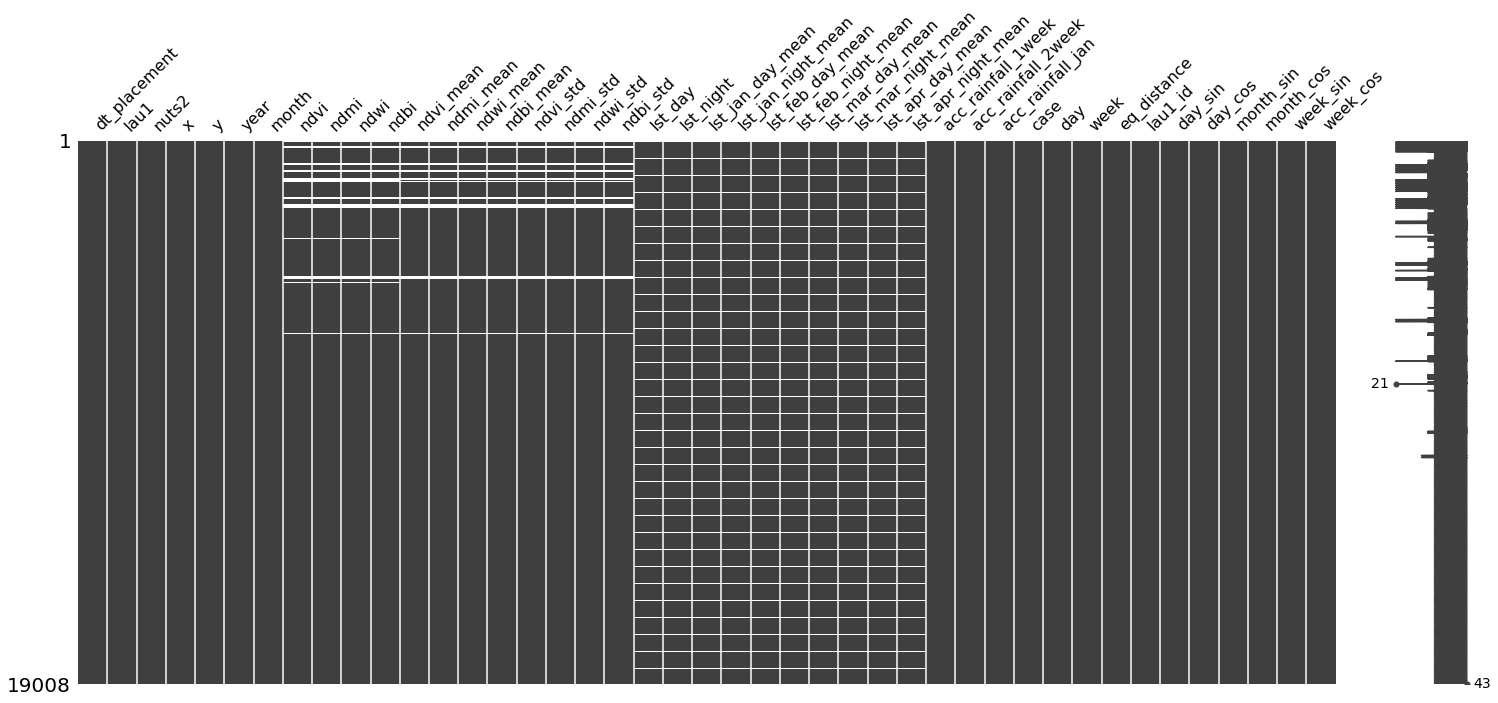

In [30]:
missingno.matrix(dataset)

In [31]:
df_demographics = pd.read_csv(f'data/{COUNTRY_CODE}_WEB_Demographics_Processed.csv', encoding = enc)

In [32]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [34]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{REGION_DEOMOGRAPHICS}'").copy()

In [35]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [36]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας βαρβαρας,2.4,10925.9,26759.0
1,αγιας παρασκευης,7.9,7557.5,62157.0
2,αγιου δημητριου,5.0,14402.8,71747.0
3,αγιων αναργυρων - καματερου,9.2,6833.8,61427.0
4,αγκιστριου,13.4,85.2,1107.0
...,...,...,...,...
61,φιλοθεης-ψυχικου,6.1,4421.0,27400.0
62,φυλης,109.1,421.2,48255.0
63,χαϊδαριου,22.7,2069.6,46983.0
64,χαλανδριου,10.8,6869.6,77118.0


In [37]:
##temporary cell
process_greek(df_demographics_nuts2, 'lau1')

In [38]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ηλιουπολεως', 'ηρακλειου αττικης', 'φιλαδελφειας χαλκηδονος']

Length: 3


In [39]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηλιουπολης','ηλιουπολεως'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρακλειου','ηρακλειου αττικης'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νεας φιλαδελφειας νεας χαλκηδονας','φιλαδελφειας χαλκηδονος'))


In [40]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [41]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

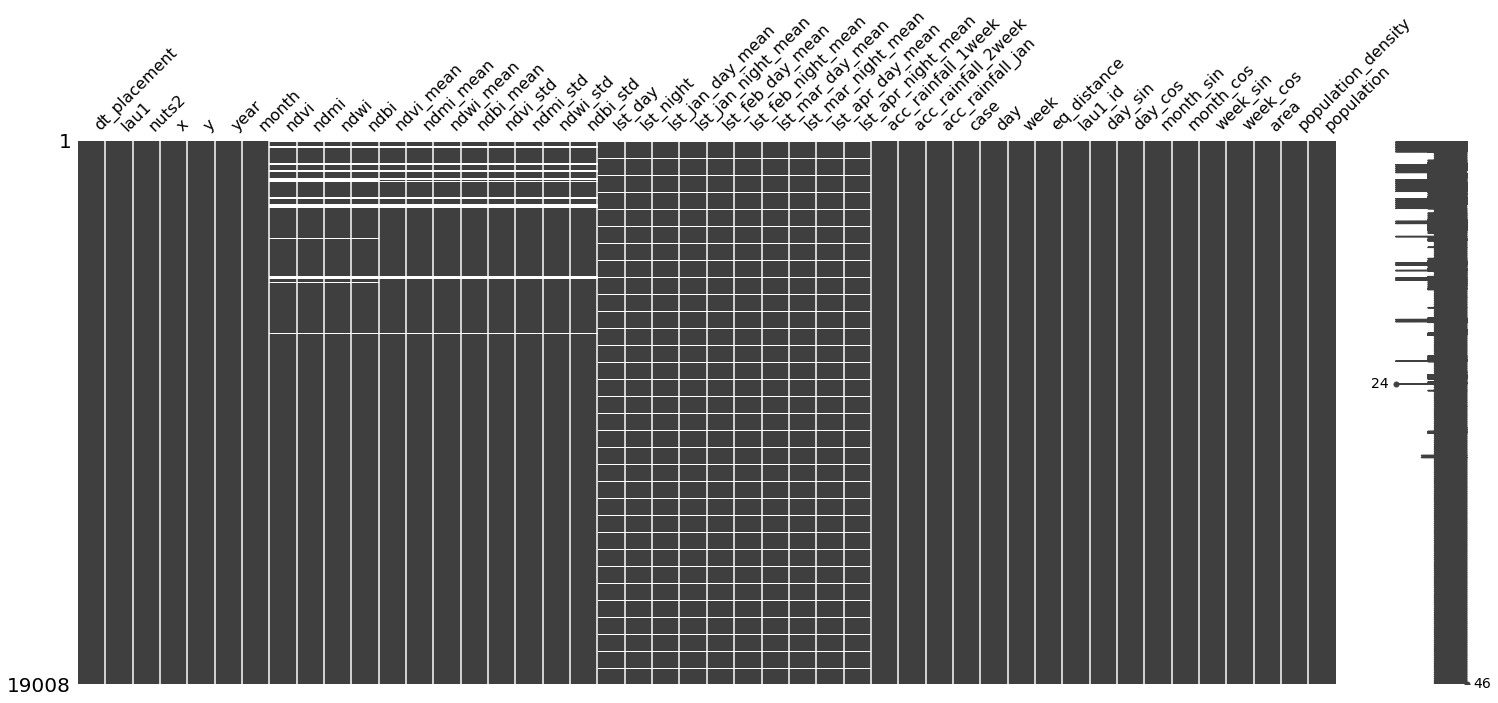

In [42]:
missingno.matrix(dataset)

In [43]:
missing = describe_dataframe(dataset)

C:\Users\dimit\AppData\Local\Temp/ipykernel_10344/1779066899.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_desc = df_desc.append({'Column': col,
C:\Users\dimit\AppData\Local\Temp/ipykernel_10344/1779066899.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_desc = df_desc.append({'Column': col,
C:\Users\dimit\AppData\Local\Temp/ipykernel_10344/1779066899.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_desc = df_desc.append({'Column': col,
C:\Users\dimit\AppData\Local\Temp/ipykernel_10344/1779066899.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_desc = df_desc.append({'Column': col,
C:\Users\dimit\AppData\L

In [44]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,12.5,15.7,0.000000,0,1,53,44.75555,26,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,2.4,10925.9,26759.0
1,2010-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,11.8,15.9,0.000000,0,1,53,44.85879,49,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,7.9,7557.5,62157.0
2,2010-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,15.0,18.5,0.000000,0,1,53,44.74465,23,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,5.0,14402.8,71747.0
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2010,1,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,10.8,16.1,0.000000,0,1,53,44.83209,43,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.2,6833.8,61427.0
4,2010-01-01,αγκιστριου,αττικης,23.34009,37.69503,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,9.0,16.1,0.000000,0,1,53,44.33593,5,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,13.4,85.2,1107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2021,12,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,0.0,0.0,485.950000,0,16,50,44.83787,45,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,6.1,4421.0,27400.0
19004,2021-12-16,φυλης,αττικης,23.68862,38.10670,2021,12,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,0.0,0.0,477.866667,0,16,50,44.86949,52,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,109.1,421.2,48255.0
19005,2021-12-16,χαλανδριου,αττικης,23.80941,38.02226,2021,12,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,0.0,0.0,512.600000,0,16,50,44.86179,50,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,10.8,6869.6,77118.0
19006,2021-12-16,χαϊδαριου,αττικης,23.63084,38.00942,2021,12,0.167201,0

In [45]:
mosquito_data = read_data(f'data/{COUNTRY_CODE}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [46]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [47]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY' | nuts2 == 'CENTRAL MACEDONIA'").copy()
#mosquito_data_attica = mosquito_data.copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [48]:
mosq_columns = mosquito_data_nuts2.columns

In [49]:
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [51]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


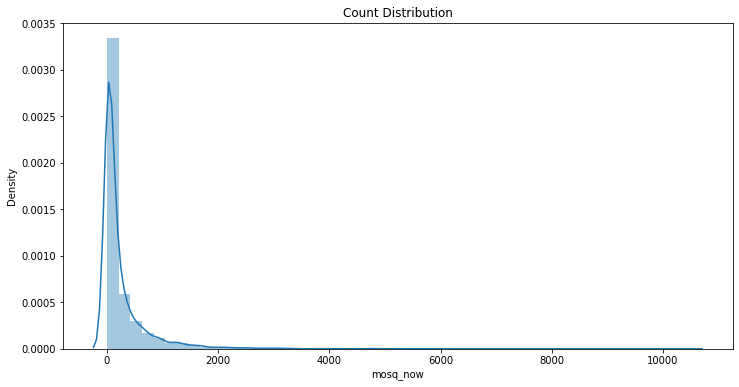

In [52]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [53]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_10344/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


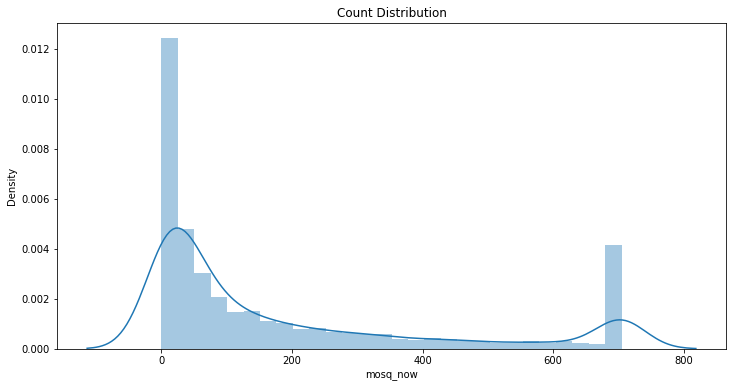

In [54]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

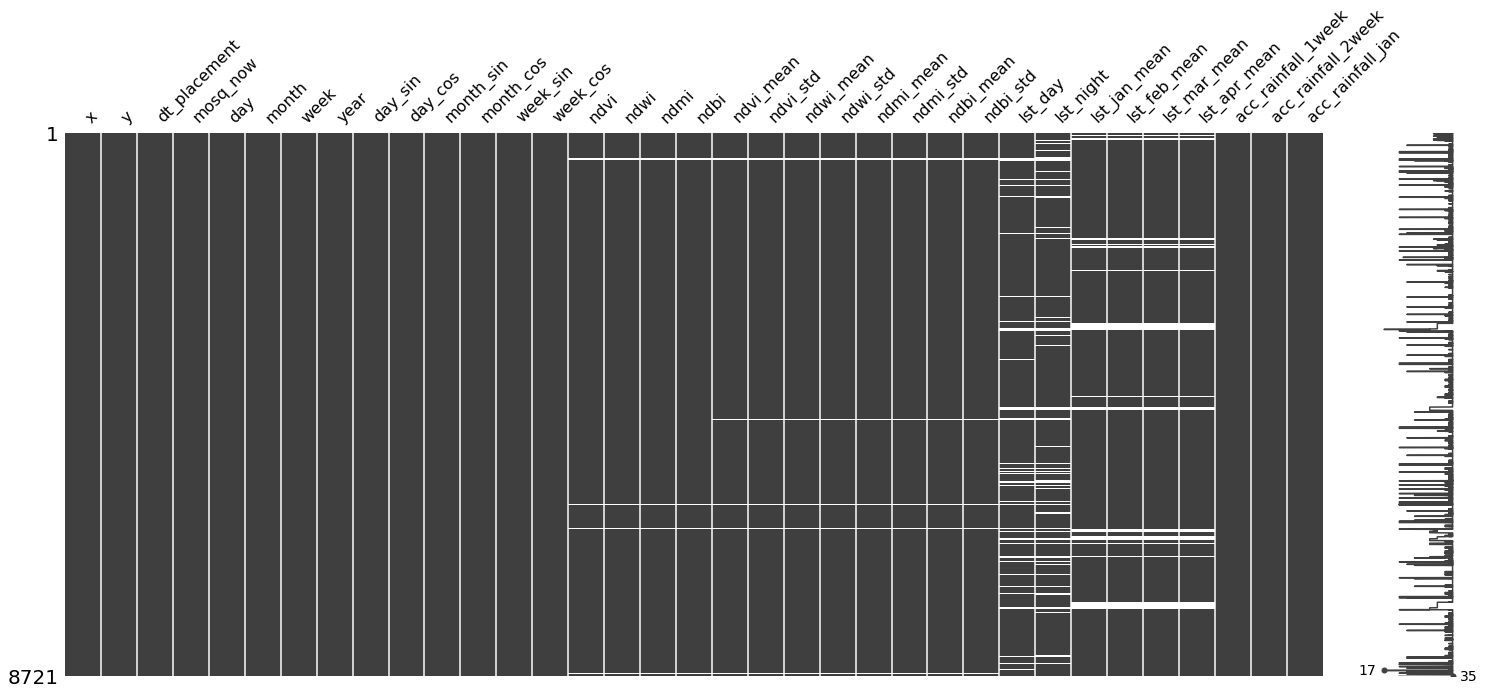

In [55]:
missingno.matrix(mosquito_data_nuts2)

In [56]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [57]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

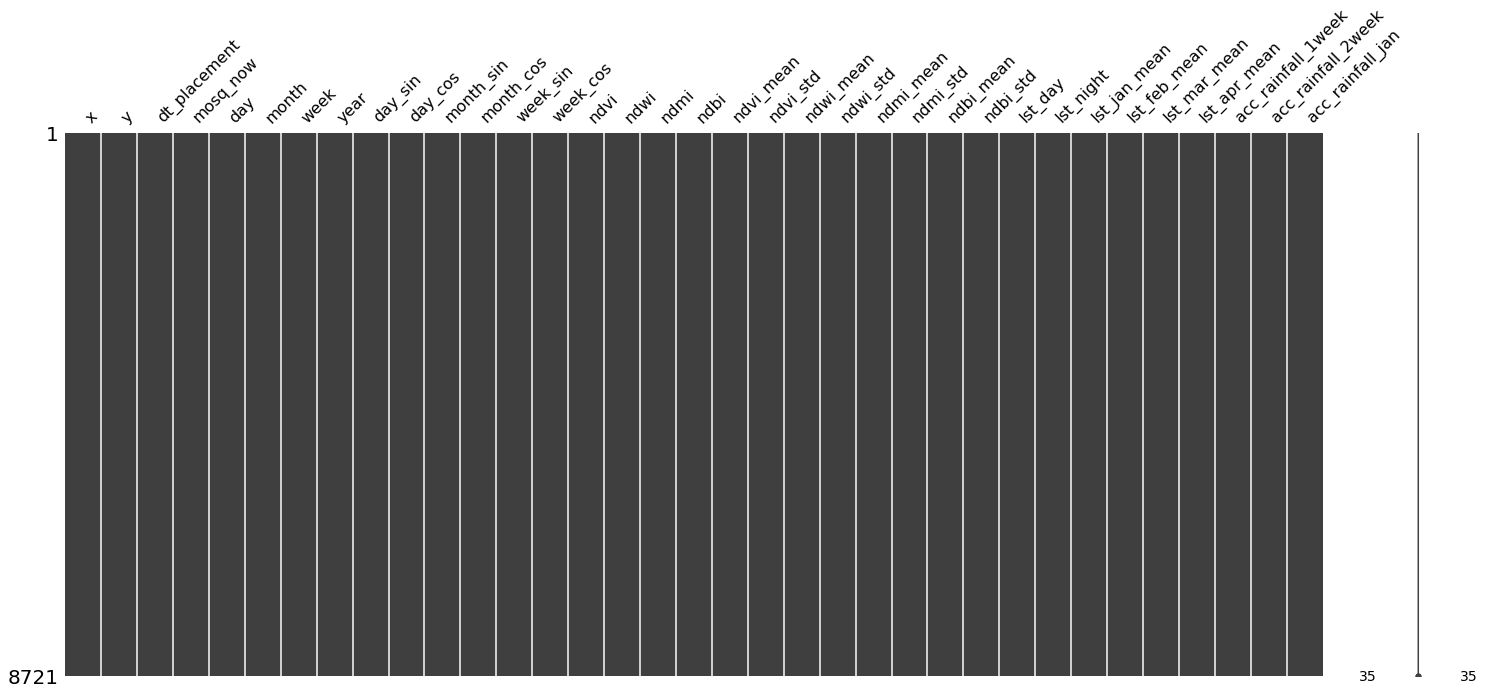

In [58]:
missingno.matrix(mosquito_data_nuts2)

In [59]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [60]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  71. 705.]


f:\My Drive\NOA\MBD-Prediction\Greece\../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.loc[:,'mosq_bins(t+1)'] =  culex
f:\My Drive\NOA\MBD-Prediction\Greece\../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.loc[:,'mosq_bins(t+1)'] =  culex
f:\My Drive\NOA\MBD-Prediction\Greece\../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

In [61]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 21.82049 | Val Loss: 26.85215 | Train Acc: 2.765| Val Acc: 2.199
Epoch 002: | Train Loss: 20.97683 | Val Loss: 24.07750 | Train Acc: 2.409| Val Acc: 2.212
Epoch 003: | Train Loss: 19.89039 | Val Loss: 24.05785 | Train Acc: 2.239| Val Acc: 2.080
Epoch 004: | Train Loss: 19.56601 | Val Loss: 24.78687 | Train Acc: 2.176| Val Acc: 2.108
Epoch 005: | Train Loss: 19.42523 | Val Loss: 24.20196 | Train Acc: 2.164| Val Acc: 2.124
Epoch 006: | Train Loss: 19.02428 | Val Loss: 24.53388 | Train Acc: 2.108| Val Acc: 2.079
Epoch 007: | Train Loss: 18.94904 | Val Loss: 24.67082 | Train Acc: 2.120| Val Acc: 2.100
Epoch 008: | Train Loss: 19.14611 | Val Loss: 24.26198 | Train Acc: 2.150| Val Acc: 2.152
Epoch 009: | Train Loss: 18.87903 | Val Loss: 24.01535 | Train Acc: 2.119| Val Acc: 2.145
Epoch 010: | Train Loss: 18.58539 | Val Loss: 24.35959 | Train Acc: 2.085| Val Acc: 2.117
Epoch 011: | Train Loss: 18.61346 | Val Loss: 24.27158 | Train Acc: 2.103| Val Acc: 2.179
Epoch 012:

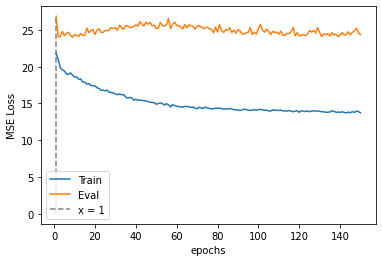

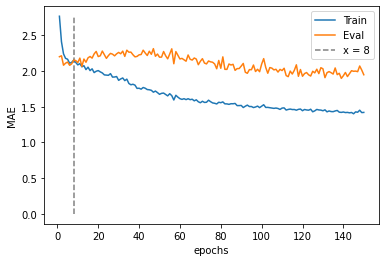

In [62]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [65]:
metrics(train, test, threshold=30)

MAE on train set:  130.40451080086947
min prediction: 1
max prediction: 1120

MAE on test set:  137.74274293032647
Error ⩽ 30: 21.28 %
min prediction: 1
max prediction: 1090


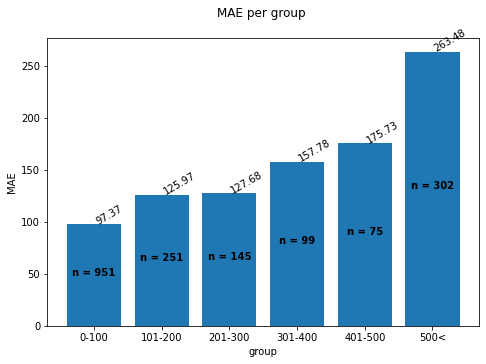

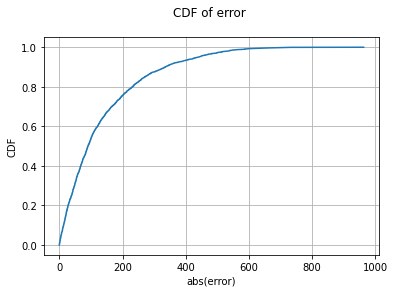

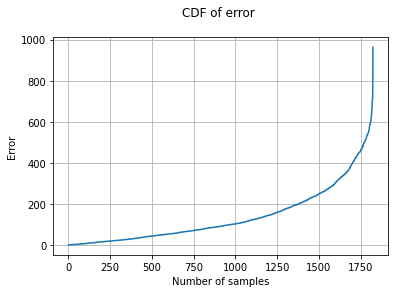

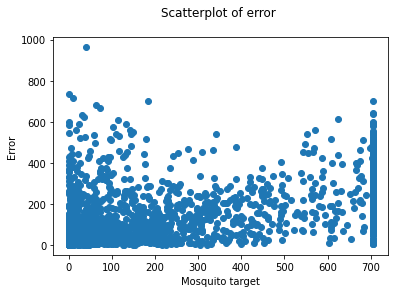

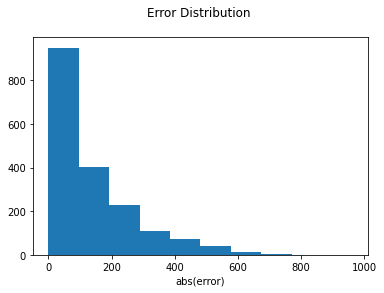

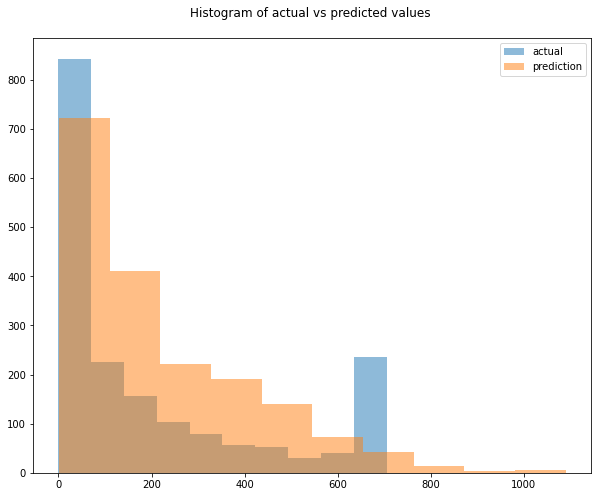

In [66]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 15.13908 | Val Loss: 7.86078 | Train Acc: 1.613| Val Acc: 2.921
Epoch 002: | Train Loss: 15.23258 | Val Loss: 7.81080 | Train Acc: 1.622| Val Acc: 2.921
Epoch 003: | Train Loss: 15.33539 | Val Loss: 7.12535 | Train Acc: 1.632| Val Acc: 2.921
Epoch 004: | Train Loss: 15.08086 | Val Loss: 7.84566 | Train Acc: 1.590| Val Acc: 2.921
Epoch 005: | Train Loss: 14.98462 | Val Loss: 5.19954 | Train Acc: 1.584| Val Acc: 1.921
Epoch 006: | Train Loss: 15.07681 | Val Loss: 10.75602 | Train Acc: 1.579| Val Acc: 2.921
Epoch 007: | Train Loss: 14.89985 | Val Loss: 13.32671 | Train Acc: 1.573| Val Acc: 3.921
Epoch 008: | Train Loss: 14.83185 | Val Loss: 12.13504 | Train Acc: 1.554| Val Acc: 3.921
Epoch 009: | Train Loss: 14.78322 | Val Loss: 10.21580 | Train Acc: 1.539| Val Acc: 2.921
Epoch 010: | Train Loss: 14.78090 | Val Loss: 10.33437 | Train Acc: 1.544| Val Acc: 2.921
Epoch 011: | Train Loss: 14.64280 | Val Loss: 9.06130 | Train Acc: 1.522| Val Acc: 2.921
Epoch 012: | Tra

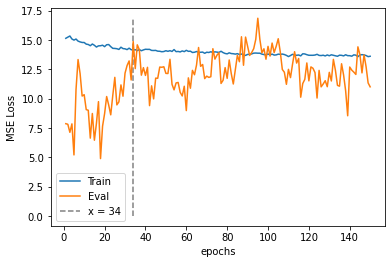

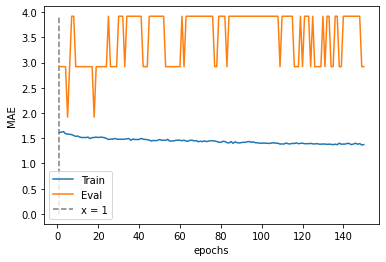

In [67]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [ ]:
# mamoth_columns = ['x','y','dt_placement','day','month','week','year', 
#                   'day_sin','day_cos','month_sin','month_cos','week_sin','week_cos',
#                   'ndvi','ndmi','ndwi','ndbi', 'ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean', 
#                   'ndvi_std','ndmi_std','ndwi_std','ndbi_std',
#                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean', 
#                   'acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_jan', 'mosq_now' ]

In [68]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [69]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [70]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [71]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [72]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [73]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

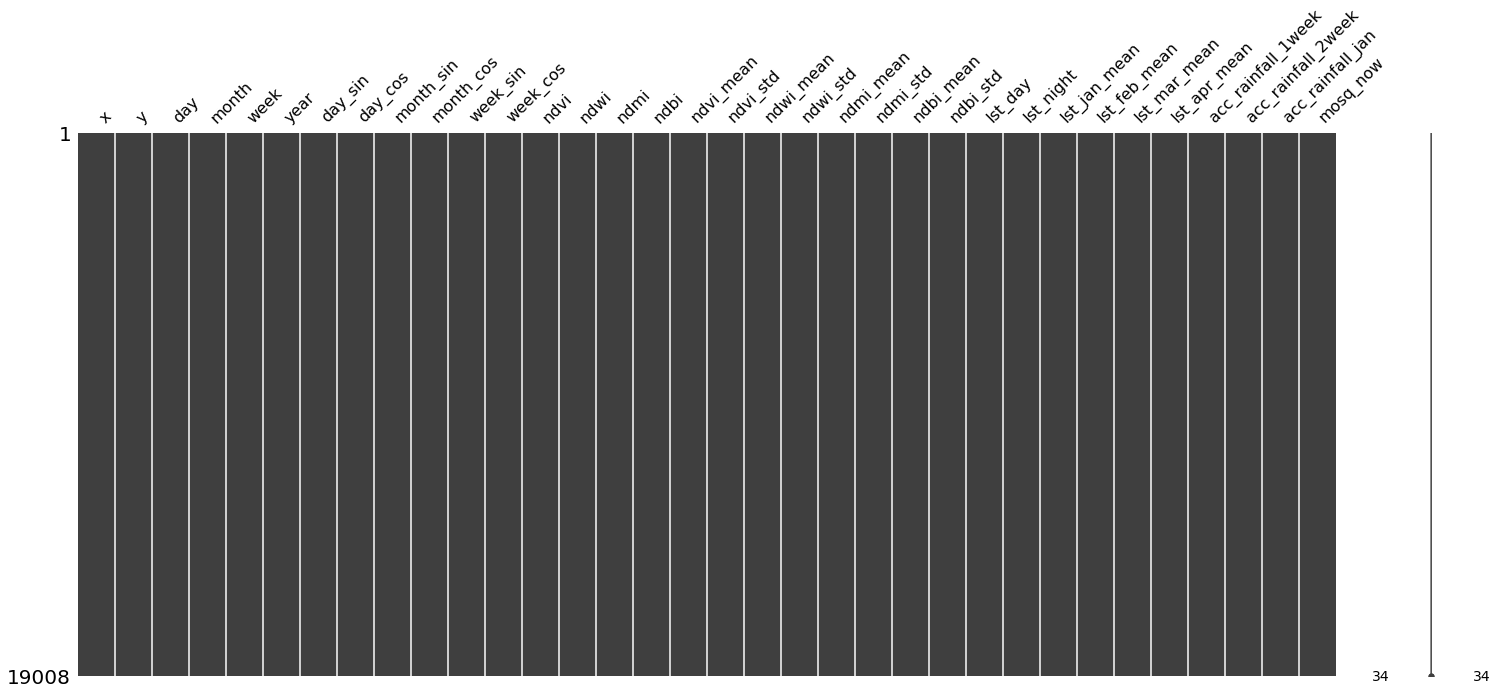

In [74]:
missingno.matrix(dataset_mamoth)

In [75]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [76]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [77]:
predictions = give_predictions(model, dataset_mamoth)

In [78]:
mosqutio_predictions['mosq_pred'] = predictions

In [79]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.65697,37.99220,2010-01-01,1
1,23.82642,38.00806,2010-01-01,1
2,23.73031,37.93357,2010-01-01,1
3,23.71341,38.04721,2010-01-01,15
4,23.34009,37.69503,2010-01-01,1
...,...,...,...,...
19003,23.77628,38.01477,2021-12-16,52
19004,23.68862,38.10670,2021-12-16,156
19005,23.80941,38.02226,2021-12-16,5
19006,23.63084,38.00942,2021-12-16,1


In [80]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x','y','dt_placement'])

In [81]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,12.5,15.7,0.000000,0,1,53,44.75555,26,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,2.4,10925.9,26759.0,1
1,2010-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,11.8,15.9,0.000000,0,1,53,44.85879,49,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,7.9,7557.5,62157.0,1
2,2010-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,15.0,18.5,0.000000,0,1,53,44.74465,23,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,5.0,14402.8,71747.0,1
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2010,1,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,10.8,16.1,0.000000,0,1,53,44.83209,43,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.2,6833.8,61427.0,15
4,2010-01-01,αγκιστριου,αττικης,23.34009,37.69503,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,9.0,16.1,0.000000,0,1,53,44.33593,5,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,13.4,85.2,1107.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19003,2021-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2021,12,0.316559,0.137485,-0.282544,-0.137485,0.283007,0.127313,-0.263474,-0.127313,0.031133,0.023760,0.026578,0.023760,14104.000000,13787.000000,14301.555556,14018.538462,14526.125000,14088.473684,14612.416667,14045.800000,14942.200000,14225.588235,0.0,0.0,485.950000,0,16,50,44.83787,45,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,6.1,4421.0,27400.0,52
19004,2021-12-16,φυλης,αττικης,23.68862,38.10670,2021,12,0.346703,0.085737,-0.311130,-0.085737,0.090410,0.162947,-0.049830,-0.162947,0.020864,0.020859,0.015204,0.020859,14057.666667,13689.333333,14155.346348,13835.097222,14407.651593,13977.813045,14452.244444,13881.838492,14747.583333,14047.326923,0.0,0.0,477.866667,0,16,50,44.86949,52,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,109.1,421.2,48255.0,156
19005,2021-12-16,χαλανδριου,αττικης,23.80941,38.02226,2021,12,0.208161,0.102706,-0.203557,-0.102706,0.231337,0.108577,-0.220864,-0.108577,0.046638,0.032328,0.030636,0.032328,14290.000000,13786.000000,14345.875000,13999.923077,14503.222222,14080.400000,14571.833333,14052.533333,14912.333333,14207.307692,0.0,0.0,512.600000,0,16,50,44.86179,50,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,10.8,6869.6,77118.0,5
19006,2021-12-16,χαϊδαριου,αττικης,23

<AxesSubplot:>

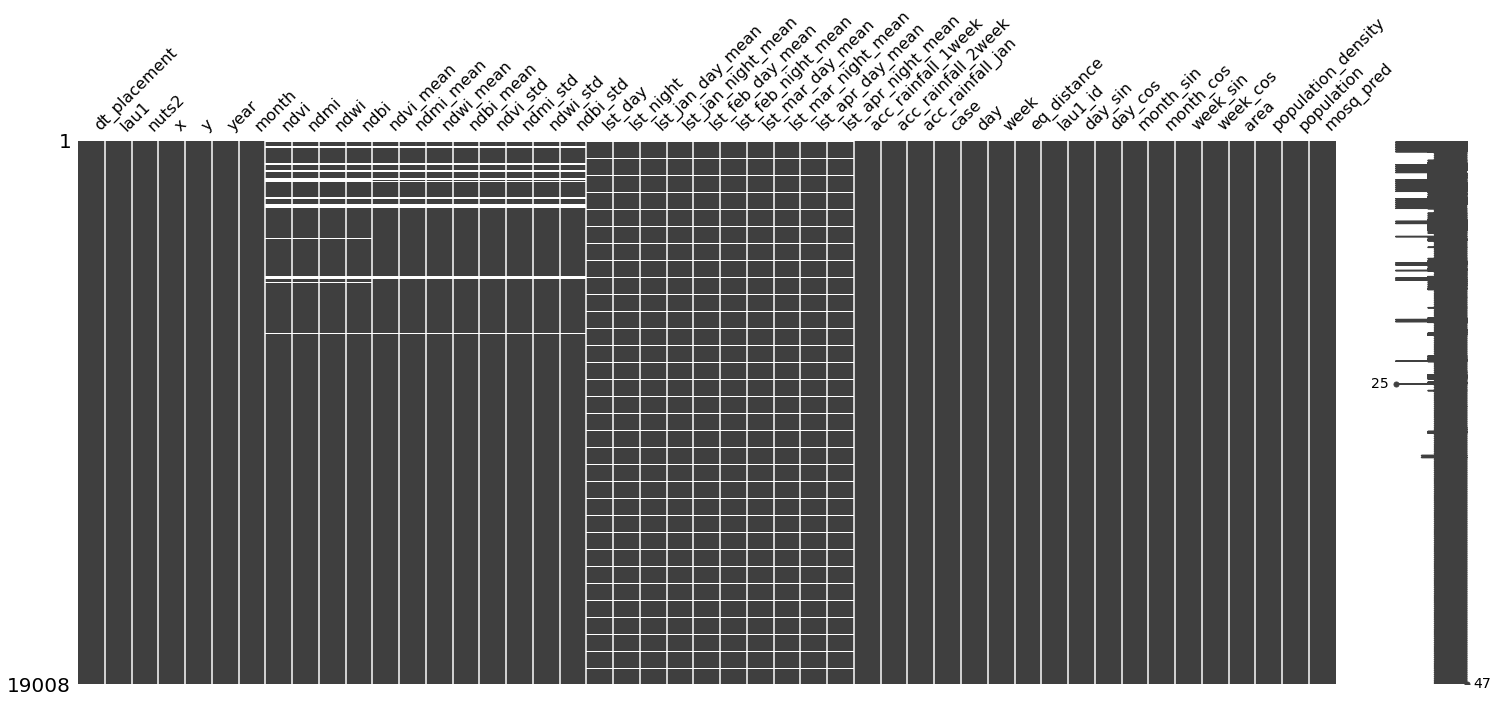

In [82]:
missingno.matrix(dataset)

In [83]:
dataset.reset_index(inplace=True, drop=True)

In [84]:
dataset = calculate_mosq_previous(dataset)

In [85]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

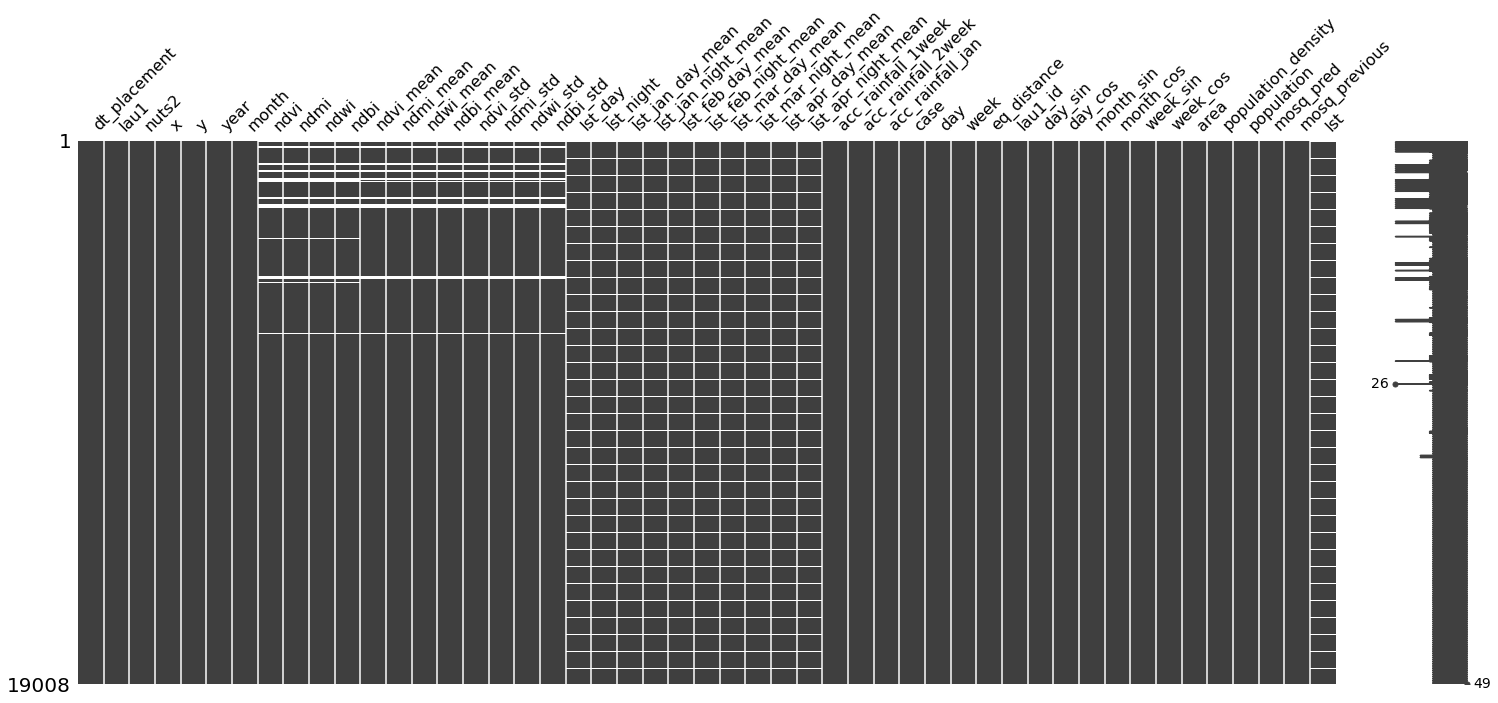

In [86]:
missingno.matrix(dataset)

In [87]:
dataset['case'].value_counts()

0     18836
1       122
2        27
3        11
4         5
6         3
5         2
11        1
9         1
Name: case, dtype: int64

In [88]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [89]:
dataset = convert_multiple_cases(dataset)

C:\Users\dimit\AppData\Local\Temp/ipykernel_10344/1779066899.py:114: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataframe = dataframe.append([dataframe[dataframe[target_col] == case_count]] * (case_count - 1), ignore_index=True)


In [90]:
dataset['case'].value_counts()

0    18836
1      277
Name: case, dtype: int64

In [91]:
cols = dataset.columns

In [ ]:
# check columns

In [92]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [93]:
dataset_final = dataset[final_columns].copy()

In [94]:
dataset_final

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,26,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482000,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,12.5,15.7,0.0,1,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,49,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890000,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,11.8,15.9,0.0,1,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,23,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805000,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,15.0,18.5,0.0,1,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,43,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010000,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,10.8,16.1,0.0,15,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,5,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615000,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,9.0,16.1,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19108,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,6.0,295.9,234,476,1
19109,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,6.0,295.9,234,476,1
19110,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,6.0,295.9,234,476,1
19111,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444

In [95]:
dataset_final.to_csv(f"data/{COUNTRY_CODE}_{REGION}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)